In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, glob, os
import scipy.stats as stats, scipy.io as sio
from statsmodels.stats.multitest import fdrcorrection


### Objective
0. Run after neur4.ipynb
1. Investigate shape axes, both within and across boundary contexts

### helpers (from neur4)

In [3]:
def get_pt_metadata(patient, verbose=True):
    pt_data_dir = f'../../results/2025{patient}/records/processed_data'
    pt_psychopy_df = psychopy_df.loc[psychopy_df['subj'] == patient].reset_index(drop=True)
    pt_neur_df     = pd.read_parquet(f'{pt_data_dir}/df_neurs.parquet')
    pt_num_neurs   = len(pt_neur_df)
    if verbose: print(f'patient={patient}', f'num_trials={len(pt_psychopy_df)}', f'num_neurons={pt_num_neurs}\n')
    return pt_psychopy_df, pt_neur_df, pt_num_neurs


def get_pt_epoch_spike_data(patient, epoch, verbose=True):
    pt_data_dir = f'../../results/2025{patient}/records/processed_data'
    pt_epoch_spikes     = np.load(f'{pt_data_dir}/{epoch}_spikes.npy', allow_pickle=True)
    pt_epoch_num_spikes = np.array([[len(pt_epoch_spikes[t, n]) for n in range(pt_epoch_spikes.shape[1])]
                                    for t in range(pt_epoch_spikes.shape[0])])
    pt_epoch_FRs  = np.load(f'{pt_data_dir}/{epoch}_FRs.npy', allow_pickle=True)
    pt_epoch_bins = np.load(f'{pt_data_dir}/{epoch}_bin_centers.npy', allow_pickle=True)
    if verbose:
        print(f'patient={patient}, epoch={epoch}')
        print(f'spikes (trials, neurons): {pt_epoch_spikes.shape}')
        print(f'FRs (trials, neurons, bins): {pt_epoch_FRs.shape}')
    return pt_epoch_spikes, pt_epoch_num_spikes, pt_epoch_FRs, pt_epoch_bins


def get_contrast_in_epoch(psychopy_df, contrast, verbose=True):
    cont_trials, cont_labels = [], []
    if contrast == 'boundary_context':
        for cond in ['curv_comp', 'baseline', 'flat_comp']:
            cont_trials.append(psychopy_df[psychopy_df['condition'] == cond].index)
            cont_labels.append(cond)
    elif contrast == 'shape':
        cont_trials.append(psychopy_df[psychopy_df['shape'] == 'curv'].index)
        cont_trials.append(psychopy_df[psychopy_df['shape'] == 'flat'].index)
        cont_labels += ['curv', 'flat']
    elif contrast == 'valence':
        cont_trials.append(psychopy_df[psychopy_df['stim_pos_aligned'] > psychopy_df['div_pos_aligned']].index)
        cont_trials.append(psychopy_df[psychopy_df['stim_pos_aligned'] < psychopy_df['div_pos_aligned']].index)
        cont_labels += ['gain', 'loss']
    if verbose: print(f'contrast: {contrast}')
    return cont_trials, cont_labels


1. Investigate shape axes, both within and across boundary contexts

In [4]:
psychopy_df = pd.read_csv('../../results/psychopy/all_subjs_clean.csv')
psychopy_df = psychopy_df[['trial_key', *psychopy_df.columns.difference(['trial_key'], sort=False)]]
patients = psychopy_df['subj'].unique().tolist()
for patient in [9, 11]: patients.remove(patient)
print(f'neural patients: {patients}')

neural patients: [12, 18, 21, 22]


### PCA: avg stim-epoch activation per stim_pos, split by boundary context

In [5]:
from sklearn.decomposition import PCA

epoch = 'stim'
conditions = ['baseline', 'curv_comp', 'flat_comp']

# 1. per-patient: time-average FRs across bins, then z-score per neuron across all trials
pt_data = {}
for patient in patients:
    pt_psychopy_df, _, _ = get_pt_metadata(patient, verbose=False)
    _, _, pt_epoch_FRs, _ = get_pt_epoch_spike_data(patient, epoch, verbose=False)
    n_neurs   = pt_epoch_FRs.shape[1]           # use spike-array neuron count (safe vs df_neurs mismatch)
    mean_FRs  = pt_epoch_FRs.mean(axis=2)        # (240, n_neurs)
    z_FRs     = (mean_FRs - mean_FRs.mean(0)) / (mean_FRs.std(0) + 1e-8)
    pt_data[patient] = {'psychopy': pt_psychopy_df, 'z_FRs': z_FRs, 'n_neurs': n_neurs}

# 2. per condition × stim_pos: average z_FRs within each patient
cond_pt_means = {}
for cond in conditions:
    cond_pt_means[cond] = {}
    for patient in patients:
        d    = pt_data[patient]
        mask = (d['psychopy']['condition'] == cond).values
        pos  = d['psychopy'].loc[mask, 'stim_pos'].round(2).values
        z    = d['z_FRs'][mask]
        df_tmp = pd.DataFrame(z)
        df_tmp['stim_pos'] = pos
        cond_pt_means[cond][patient] = df_tmp.groupby('stim_pos').mean()  # (n_unique_pos, n_neurs)

# 3. build joint matrix per condition: rows = union of stim_pos, cols = all neurons across patients
total_neurs = sum(pt_data[pt]['n_neurs'] for pt in patients)
cond_matrices, cond_pos_values = {}, {}

for cond in conditions:
    all_pos = sorted(set().union(*[set(cond_pt_means[cond][pt].index) for pt in patients]))
    M = np.zeros((len(all_pos), total_neurs))
    col_offset = 0
    for patient in patients:
        n        = pt_data[patient]['n_neurs']
        pt_means = cond_pt_means[cond][patient]
        for i, pos in enumerate(all_pos):
            if pos in pt_means.index:
                M[i, col_offset:col_offset + n] = pt_means.loc[pos].values
        col_offset += n
    cond_matrices[cond]   = M
    cond_pos_values[cond] = np.array(all_pos)
    print(f'{cond}: {len(all_pos)} unique stim_pos values, matrix {M.shape}')

print(f'\ntotal neurons across patients: {total_neurs}')

baseline: 20 unique stim_pos values, matrix (20, 57)
curv_comp: 15 unique stim_pos values, matrix (15, 57)
flat_comp: 15 unique stim_pos values, matrix (15, 57)

total neurons across patients: 57


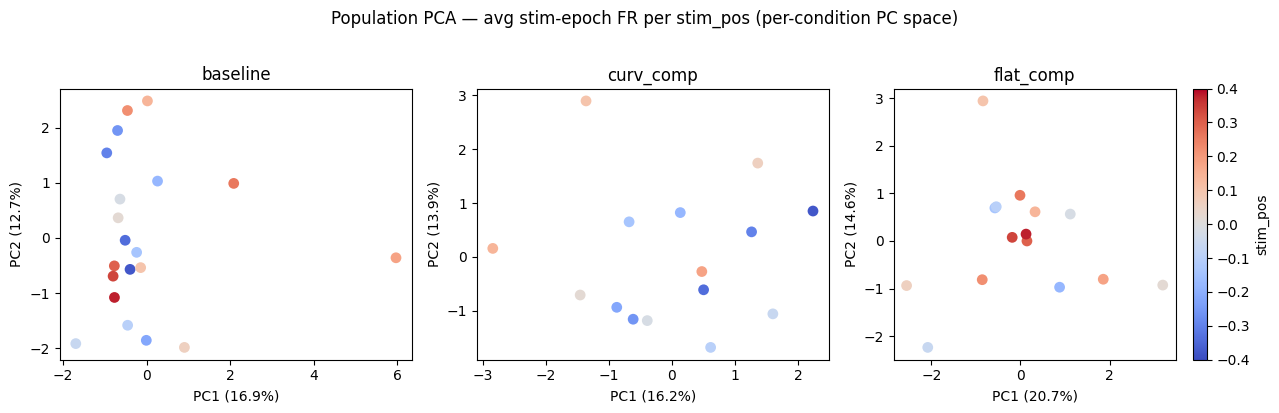

In [6]:
# Plot 1: per-condition PCA — each subplot is its own PC space
fig, axs = plt.subplots(1, 3, figsize=(13, 4))
for ax, cond in zip(axs, conditions):
    pca  = PCA(n_components=2)
    coords = pca.fit_transform(cond_matrices[cond])
    ev   = pca.explained_variance_ratio_
    sc   = ax.scatter(coords[:, 0], coords[:, 1],
                      c=cond_pos_values[cond], cmap='coolwarm', vmin=-0.4, vmax=0.4,
                      s=60, linewidths=0)
    ax.set(title=cond, xlabel=f'PC1 ({ev[0]*100:.1f}%)', ylabel=f'PC2 ({ev[1]*100:.1f}%)')

plt.colorbar(sc, ax=axs[-1], label='stim_pos')
plt.suptitle(f'Population PCA — avg {epoch}-epoch FR per stim_pos (per-condition PC space)', y=1.02)
plt.tight_layout()
plt.show()

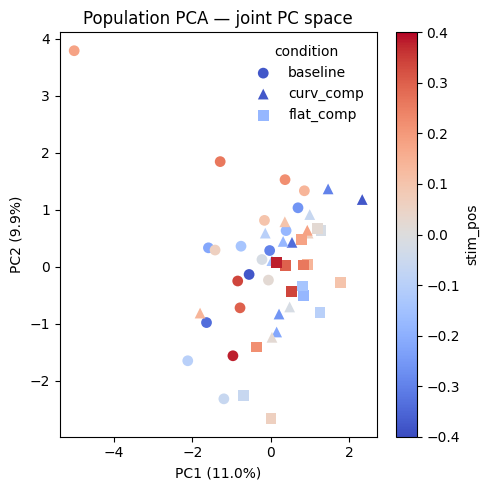

In [7]:
# Plot 2: joint PCA — shared PC space, conditions distinguished by marker shape
X_all     = np.vstack([cond_matrices[c] for c in conditions])
pca_joint = PCA(n_components=2).fit(X_all)
ev_j      = pca_joint.explained_variance_ratio_

markers = {'baseline': 'o', 'curv_comp': '^', 'flat_comp': 's'}
fig, ax = plt.subplots(figsize=(5, 5))
for cond in conditions:
    coords = pca_joint.transform(cond_matrices[cond])
    sc = ax.scatter(coords[:, 0], coords[:, 1],
                    c=cond_pos_values[cond], cmap='coolwarm', vmin=-0.4, vmax=0.4,
                    s=60, marker=markers[cond], linewidths=0, label=cond)

plt.colorbar(sc, ax=ax, label='stim_pos')
ax.legend(title='condition', loc='best', frameon=False)
ax.set(title=f'Population PCA — joint PC space',
       xlabel=f'PC1 ({ev_j[0]*100:.1f}%)', ylabel=f'PC2 ({ev_j[1]*100:.1f}%)')
plt.tight_layout()
plt.show()